# Installation of Pyteseract

In [ ]:
!sudo apt install tesseract-ocr
!pip install pytesseract
!apt-get install tesseract-ocr-ara

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 21 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 1s (4,308 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debc

# Importing Libraries and defining Functions

In [ ]:
import cv2
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import pytesseract
from PIL import Image

# Bounding outer and inner

In [ ]:
def get_bounding_outer(thresh_image, img):
  # report = []
  # ROI_number = 0
  original=img.copy()
  cnts = cv2.findContours( thresh_image , cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  cnts = cnts[0] if len(cnts) == 2 else cnts[1]
  # cnts = sorted(cnts, key=lambda x: (cv2.boundingRect(x)[1], cv2.boundingRect(x)[0]))  # Sor

  ROI = []
  for c in cnts:
      x,y,w,h = cv2.boundingRect(c)
      cv2.rectangle(original, (x, y), (x + w, y + h), (36,255,12), 2)
      ROI.append(img[y:y + h, x:x + w])
      # report.append(pytesseract.image_to_data(ROI,lang='eng+ara', output_type=Output.DICT))
      # print(pytesseract.image_to_string(ROI, lang='eng+ara'))
      # ROI_number += 1
      # print("ROI shape:", ROI.shape)
  if len(ROI)==0:
    ROI.append(original)
  return original, ROI

In [ ]:
def get_bounding_inner(thresh_image, original_img, scale_fy=1):
    original = original_img.copy()
    cnts = cv2.findContours(thresh_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    ROI = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        # Scale coordinates back to original image size
        y_scaled = int(y / scale_fy)
        h_scaled = int(h / scale_fy)
        # Check against original image dimensions to avoid invalid regions
        if (x + w <= original_img.shape[1] and y_scaled + h_scaled <= original_img.shape[0]):
            # Check if the contour size is reasonable for a word (adjust thresholds as needed)
            if 20 < w < original_img.shape[1] and 20 < h_scaled < original_img.shape[0]:
                cv2.rectangle(original, (x, y_scaled), (x + w, y_scaled + h_scaled), (36, 255, 12), 2)
                ROI.append(original_img[y_scaled:y_scaled + h_scaled, x:x + w])
    return original, ROI

# Aspect Ratio Resize & Preprocces Functions

In [ ]:
def resize_with_aspect_ratio(image, target_width):
    # Get original dimensions
    (original_height, original_width) = image.shape[:2]

    # Calculate new height to maintain aspect ratio
    ratio = target_width / float(original_width)
    target_height = int(original_height * ratio)

    # Resize the image
    resized_image = cv2.resize(image, (target_width, target_height),
                              interpolation=cv2.INTER_AREA)
    return resized_image
def adap_thresh(image, size=21, c=16):
  size = 21
  c = size - 5
  return cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, size, c)
def remove_shadow(img):
  im = cv2.dilate(img, np.ones((3, 3), dtype=np.uint8), iterations=1)
  im = cv2.erode(im, np.ones((3, 3), dtype=np.uint8), iterations=1)
  return cv2.medianBlur(im, 3)
def stick_text(img_to_stick,width):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(width), 1))
    inv = cv2.bitwise_not(img_to_stick)
    dilated = cv2.dilate(inv, kernel, iterations=1)
    normal = cv2.bitwise_not(dilated)
    # clear_image = cv2.GaussianBlur(clear_image, (17, 1), 0)
    return normal
def stick_vertical(img_to_stick,vertical):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, int(vertical)))
    inv = cv2.bitwise_not(img_to_stick)
    dilated = cv2.dilate(inv, kernel, iterations=1)
    normal = cv2.bitwise_not(dilated)
    # clear_image = cv2.GaussianBlur(clear_image, (17, 1), 0)
    return normal
def decrease_vertical(img,vertical):
  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,int(vertical)))
  inv = cv2.bitwise_not(img)
  eroded = cv2.erode(inv, kernel, iterations=1)
  normal = cv2.bitwise_not(eroded)
  return normal
def open(img,vertical):
  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(vertical),int(vertical)))
  inv = cv2.bitwise_not(img)
  opened = cv2.morphologyEx(inv,cv2.MORPH_OPEN,kernel)
  normal = cv2.bitwise_not(opened)
  return normal
def close(img,vertical):
  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(vertical),int(vertical)))
  inv = cv2.bitwise_not(img)
  closed = cv2.morphologyEx(inv,cv2.MORPH_CLOSE,kernel)
  normal = cv2.bitwise_not(closed)
  return normal
def increase_all(img,vertical):
  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(vertical),int(vertical/8)))
  inv = cv2.bitwise_not(img)
  dilate = cv2.dilate(inv, kernel, iterations=1)
  normal = cv2.bitwise_not(dilate)
  return normal

# DeepSeek

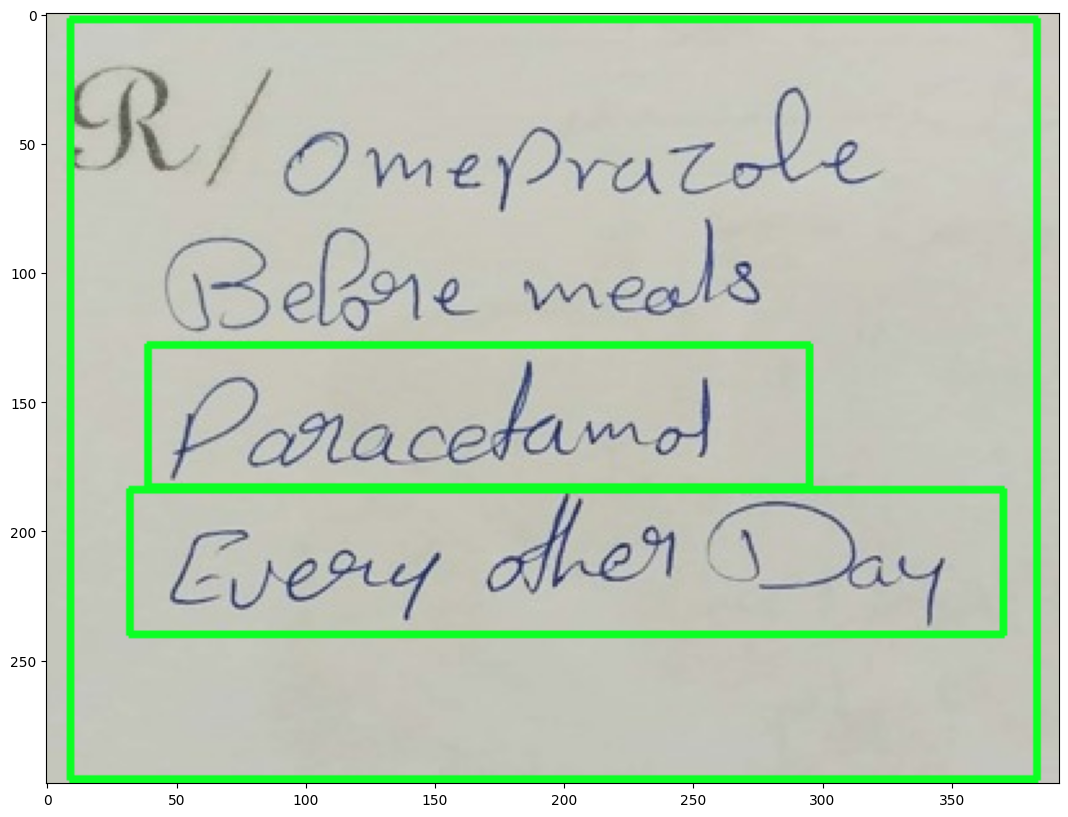

Number of ROIs detected: 3


In [ ]:
import cv2
import matplotlib.pyplot as plt

def get_bounding_inner(thresh_image, original_img, scale_fy=1):
    original = original_img.copy()
    cnts = cv2.findContours(thresh_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    ROI = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        # Scale coordinates back to original image size
        y_scaled = int(y / scale_fy)
        h_scaled = int(h / scale_fy)
        # Check against original image dimensions to avoid invalid regions
        if (x + w <= original_img.shape[1] and y_scaled + h_scaled <= original_img.shape[0]):
            # Check if the contour size is reasonable for a word (adjust thresholds as needed)
            if 20 < w < original_img.shape[1] and 20 < h_scaled < original_img.shape[0]:
                cv2.rectangle(original, (x, y_scaled), (x + w, y_scaled + h_scaled), (36, 255, 12), 2)
                ROI.append(original_img[y_scaled:y_scaled + h_scaled, x:x + w])
    return original, ROI

def adap_thresh(img):
    # Example adaptive thresholding; adjust blockSize and C as needed
    return cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

def stick_text(img_to_stick, width):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(width), 1))
    dilated = cv2.dilate(img_to_stick, kernel, iterations=1)
    return dilated

def decrease_vertical(img, vertical):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, int(vertical)))
    eroded = cv2.erode(img, kernel, iterations=1)
    return eroded

def replace_boundary_with_white(img, thickness):
    img[0:thickness, :] = 255  # Top
    img[-thickness:, :] = 255  # Bottom
    img[:, 0:thickness] = 255  # Left
    img[:, -thickness:] = 255  # Right
    return img

# Load and preprocess image
img = cv2.imread("img_10.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
scale_fy = 4  # Scaling factor for height
resized = cv2.resize(gray, None, fx=1, fy=scale_fy, interpolation=cv2.INTER_CUBIC)

# Thresholding on resized image
thresh = adap_thresh(resized)

# Morphological processing (adjusted to preserve words)
sticked = stick_text(thresh, resized.shape[1]//20)  # Reduced kernel width
fix_stick = cv2.medianBlur(sticked, 5)
fix_stick = replace_boundary_with_white(fix_stick, thickness=10)  # Reduced boundary thickness
fix_stick = decrease_vertical(fix_stick, 3)  # Reduced vertical erosion

# Find contours and draw bounding boxes
orig, rois = get_bounding_inner(fix_stick, img, scale_fy)

# Display results
plt.figure(figsize=(15,10))
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.show()
print(f"Number of ROIs detected: {len(rois)}")

# Preproccess ahmed

In [ ]:
def preprocess(image_source):
    image = cv2.imread(image_source)
    image = cv2.resize(image, None, fx=.5, fy=.5, interpolation=cv2.INTER_CUBIC)
    img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    thresh = adap_thresh(img)
    refined_image = remove_shadow(thresh)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    inv = cv2.bitwise_not(refined_image)
    dilated = cv2.dilate(inv, kernel, iterations=7)
    normal = cv2.bitwise_not(dilated)
    thresh_inv = cv2.bitwise_not(thresh)
    clear_image_inv = cv2.bitwise_and(thresh_inv, thresh_inv, mask=dilated)
    clear_image = cv2.bitwise_not(clear_image_inv)
    clear_image = cv2.medianBlur(clear_image , 3)
    clear_image = cv2.erode(clear_image, (3, 3), iterations=2)
    original, ROI = get_bounding_outer(normal, clear_image)
    pil_image = Image.fromarray(original)
    pil_image.info['dpi'] = (300, 300)
    return pil_image
def predict(image):
    custom_config = r'--oem 3 --psm 6 -c load_system_dawg=0 -c load_freq_dawg=0 -l ara+eng'
    # lis = []
    text = pytesseract.image_to_string(image, config=custom_config)
    print(text)
def gamma_correction(image, gamma=3.0):
    invGamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** invGamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)

# Add White Boundary

In [ ]:
def replace_boundary_with_white(image, thickness=10):

    # Create a copy to avoid modifying the original
    modified = image.copy()

    # Set white color (BGR for color images, 255 for grayscale)
    white = (255, 255, 255) if len(image.shape) == 3 else 255

    # Replace top boundary
    modified[:thickness, :] = white  # Top edge
    # Replace bottom boundary
    modified[-thickness:, :] = white  # Bottom edge
    # Replace left boundary
    modified[:, :thickness] = white  # Left edge
    # Replace right boundary
    modified[:, -thickness:] = white  # Right edge

    return modified

# Test Replace Boundary

In [ ]:
# img=cv2.imread('image_1.jpg')
# img = replace_boundary_with_white(img, thickness=30)
# plt.imshow(img)
# plt.show()
# print(img.shape)

## Testing Gamma Correction

In [ ]:
img=cv2.imread('image_1.jpg')
# gm=gamma_correction(img,3)
# plt.imshow(gm,cmap='gray')
# plt.show()

# Test Resize with aspect ratio maintained

TypeError: Image data of dtype object cannot be converted to float

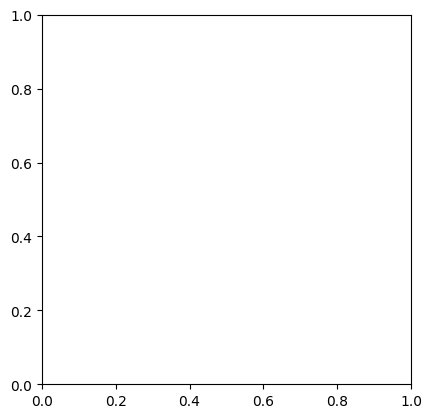

In [ ]:
plt.imshow(img)
plt.show()
print(img.shape[0]/img.shape[1])
img=resize_with_aspect_ratio(img,1500)
plt.imshow(img)
plt.show()
print(img.shape[0]/img.shape[1])
print(img.shape)

# Preproccess

In [ ]:
pre = preprocess('image_1.jpg')
plt.imshow(pre,cmap='gray')
plt.show()
predict(pre)

error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


# Testing Text Sticking

In [ ]:
# img=cv2.imread('image_2.jpg')
# img=resize_with_aspect_ratio(img,250)
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
rm=remove_shadow(gray)
plt.imshow(rm,cmap='gray')
plt.show()
gm_r=gamma_correction(rm,3)
plt.imshow(gm_r,cmap='gray')
plt.show()
thresh=adap_thresh(gm_r)
plt.imshow(thresh,cmap='gray')
plt.show()
sticked=stick_all(thresh,thresh.shape[1]/40)
plt.imshow(sticked,cmap='gray')
plt.show()
sticked=stick_text(sticked,thresh.shape[1]/20)
plt.imshow(sticked,cmap='gray')
plt.show()
fix_stick=cv2.medianBlur(sticked, 7)
plt.imshow(fix_stick,cmap='gray')
plt.show()

error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


# Get Outer Bounding

In [ ]:
orig,list=get_bounding_outer(fix_stick,img)
plt.imshow(orig)
print(len(list))

NameError: name 'fix_stick' is not defined

# Viewing All Outer Roi's

In [ ]:
for r in list:
  print(r.shape[0],r.shape[1])
  plt.imshow(r,cmap='gray')
  plt.show()

TypeError: 'type' object is not iterable

# Chose One Outer Roi ( MIN AREA )

In [ ]:
areas=[]
for r in list:
  areas.append(int(r.shape[0]*r.shape[1]))
chosen=list[areas.index(max(areas))]
plt.imshow(chosen,cmap='gray')

# Inner ROI Prepare

In [ ]:
c_gray=cv2.cvtColor(chosen,cv2.COLOR_BGR2GRAY)
c_rm=remove_shadow(c_gray)
plt.imshow(c_rm,cmap='gray')
plt.show()
c_gm_r=gamma_correction(c_rm,4)
plt.imshow(c_gm_r,cmap='gray')
plt.show()

In [ ]:
edges = cv2.Canny(c_gm_r , threshold1=50, threshold2=200)
plt.imshow(edges,cmap='gray')
plt.show()
_,c_thresh= cv2.threshold(edges, 1, 255, cv2.THRESH_BINARY)
plt.imshow(c_thresh,cmap='gray')
plt.show()
notted=cv2.bitwise_not(c_thresh)
sticked=stick_all(notted,c_thresh.shape[1]/30)
plt.imshow(sticked,cmap='gray')
plt.show()
sticked=stick_text(sticked,c_thresh.shape[1]/30)
plt.imshow(sticked,cmap='gray')
plt.show()
fix_stick=cv2.medianBlur(sticked, 3)
plt.imshow(fix_stick,cmap='gray')
plt.show()

# Open and Closing ( Optional )

In [ ]:
opened=open(c_thresh,9)
plt.imshow(opened,cmap='gray')
plt.show()
closed=close(opened,3)
plt.imshow(closed,cmap='gray')
plt.show()

# Get Inner ROI of Text

In [ ]:

# notted=cv2.bitwise_not(fix_stick)
# plt.imshow(notted,cmap='gray')
# plt.show()
# edges = cv2.Canny(c_gm, threshold1=50, threshold2=200)
# plt.imshow(edges,cmap='gray')
# plt.show()
# a_t=adap_thresh(c_thresh)
# plt.imshow(a_t,cmap='gray')
# plt.show()
# st_c=stick_text(notted,thresh.shape[1]/35)
# plt.imshow(st_c,cmap='gray')
# plt.show()
# c_s=cv2.medianBlur(st_c, 3)
# plt.imshow(c_s,cmap='gray')
# plt.show()
orig,list=get_bounding_outer(closed,c_rm)
plt.imshow(orig,cmap='gray')
print(len(list))

NameError: name 'closed' is not defined

# View Final Text

In [ ]:
for r in list:
  custom_config = r'--oem 3 --psm 6 -c load_system_dawg=0 -c load_freq_dawg=0 -l ara+eng'
  txt=pytesseract.image_to_string(r,config=custom_config)
  if len(txt)!=" " and len(txt)>0:
    print(txt)
    plt.imshow(r,cmap='gray')
    plt.show()


TypeError: 'type' object is not iterable

# Sentence Extraction

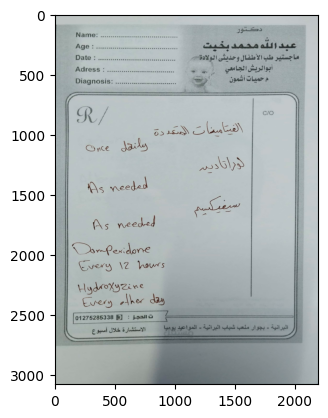

In [ ]:
img=cv2.imread("image_1.jpg")
plt.imshow(img)
plt.show()

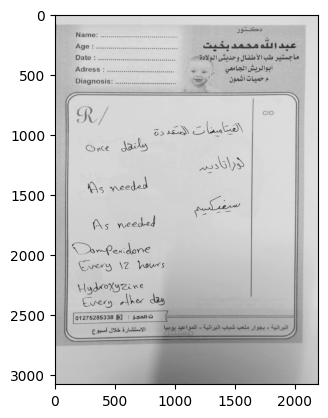

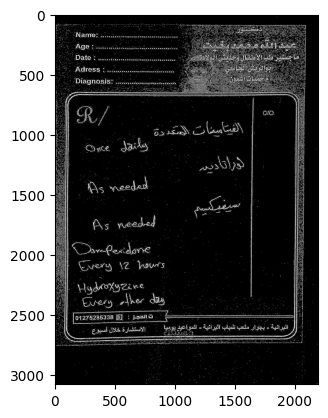

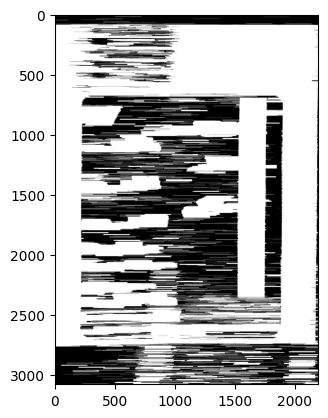

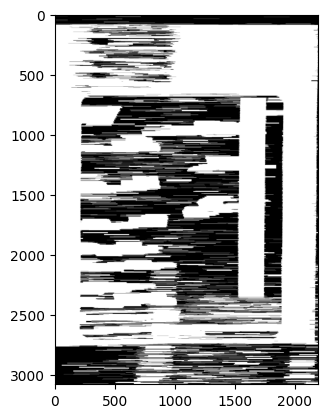

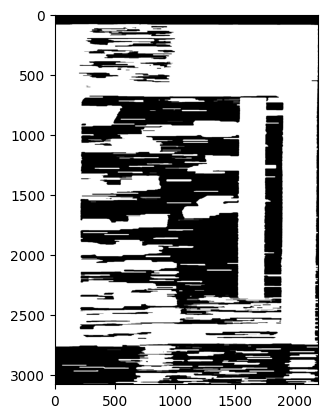

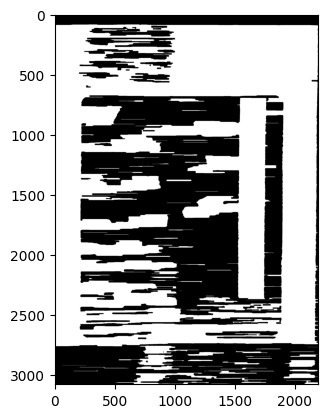

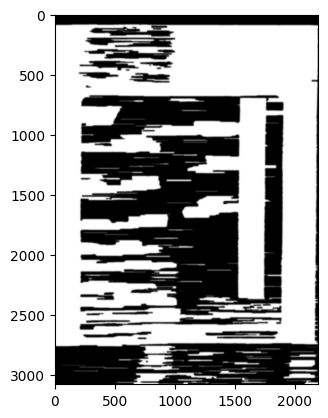

In [ ]:
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap='gray')
plt.show()
thresh=adap_thresh(gray)
plt.imshow(thresh,cmap='gray')
plt.show()
sticked=stick_text(thresh,thresh.shape[1]/10)
plt.imshow(sticked,cmap='gray')
plt.show()
dec=increase_all(sticked,11)
plt.imshow(dec,cmap='gray')
plt.show()
fix_stick=cv2.medianBlur(dec,11)
plt.imshow(fix_stick,cmap='gray')
plt.show()
# fix_stick=replace_boundary_with_white(fix_stick, thickness=30)
# plt.imshow(fix_stick,cmap='gray')
# plt.show()
fix_stick=decrease_vertical(fix_stick,7)
plt.imshow(fix_stick,cmap='gray')
plt.show()
blurred_image = cv2.GaussianBlur(fix_stick, (25,25), sigmaX=0)
plt.imshow(blurred_image,cmap='gray')
plt.show()
# edges = cv2.Canny(cv2.bitwise_not(fix_stick) , threshold1=50, threshold2=200)
# plt.imshow(edges,cmap='gray')
# plt.show()

38


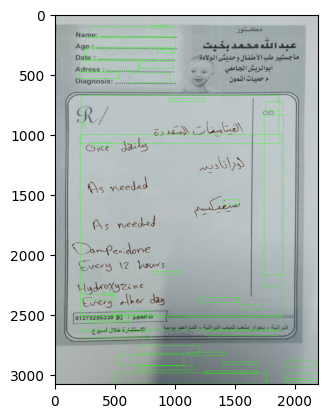

In [ ]:
orig,list=get_bounding_inner(fix_stick,img)
plt.imshow(orig,cmap='gray')
print(len(list))

In [ ]:
def is_magic(a, b, c, d, f, g, h, i):

    # The grid is:
    # [a,  b,  c,
    #  d,  5,  f,
    #  g,  h,  i]
    return (a + b + c == 15 and
            d + 5 + f == 15 and
            g + h + i == 15 and
            a + d + g == 15 and
            b + 5 + h == 15 and
            c + f + i == 15 and
            a + 5 + i == 15 and
            c + 5 + g == 15)

count = 0
solutions = []

# Loop over all positions for a, b, c, d, f, g, h, i using numbers 1-9, skipping 5.
for a in range(1, 10):
    if a == 5:
        continue
    for b in range(1, 10):
        if b == 5 or b == a:
            continue
        for c in range(1, 10):
            if c == 5 or c in (a, b):
                continue
            for d in range(1, 10):
                if d == 5 or d in (a, b, c):
                    continue
                for f in range(1, 10):
                    if f == 5 or f in (a, b, c, d):
                        continue
                    for g in range(1, 10):
                        if g == 5 or g in (a, b, c, d, f):
                            continue
                        for h in range(1, 10):
                            if h == 5 or h in (a, b, c, d, f, g):
                                continue
                            for i in range(1, 10):
                                if i == 5 or i in (a, b, c, d, f, g, h):
                                    continue
                                if is_magic(a, b, c, d, f, g, h, i):
                                    count += 1
                                    # Save the solution in row-major order (with center fixed as 5)
                                    square = [a, b, c, d, 5, f, g, h, i]
                                    solutions.append(square)

print("Total magic square arrangements found (including rotations/mirrors):", count)

# Optionally, print each solution in a 3x3 format:
for sol in solutions:
    print("------")
    print(sol[0], sol[1], sol[2])
    print(sol[3], sol[4], sol[5])
    print(sol[6], sol[7], sol[8])


Total magic square arrangements found (including rotations/mirrors): 8
------
2 7 6
9 5 1
4 3 8
------
2 9 4
7 5 3
6 1 8
------
4 3 8
9 5 1
2 7 6
------
4 9 2
3 5 7
8 1 6
------
6 1 8
7 5 3
2 9 4
------
6 7 2
1 5 9
8 3 4
------
8 1 6
3 5 7
4 9 2
------
8 3 4
1 5 9
6 7 2
